In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
file_path = '/Users/daehwankim/Documents/GitHub/AI-class_FRI123/wk_02/diabetes.csv'

# pandas의 read_csv 함수를 사용하여 파일을 데이터프레임(df)으로 읽어옵니다.
df = pd.read_csv(file_path)
display(df)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
X=df.drop('Outcome',axis=1)
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


평균제곱근오차 (sklearn): 52.23558099742444
평균제곱근오차 (numpy): 52.23558099742444
평균제곱근오차 (manual): 52.23558099742443


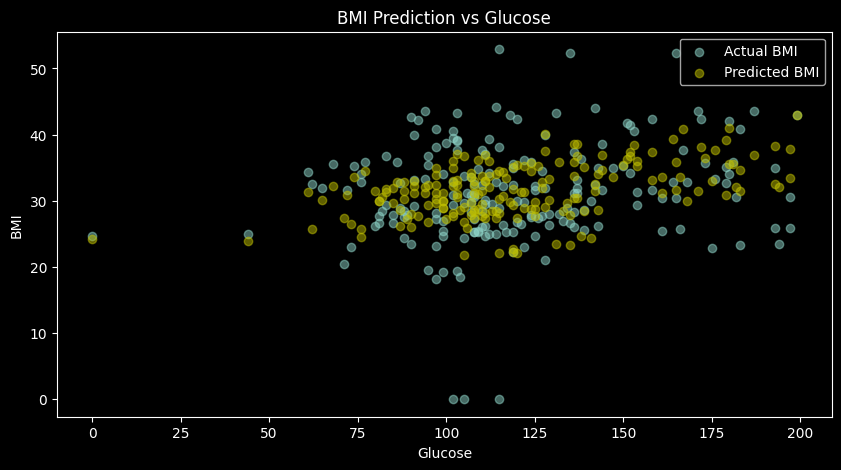

In [5]:
# Prepare data
df2 = df.copy()
y = df2['BMI']
X = df2.drop(['BMI', 'Outcome'], axis=1, errors='ignore')

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)
ly_preds = model.predict(X_test)

print('평균제곱근오차 (sklearn):', mean_squared_error(y_test, ly_preds))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차 (numpy):', mse_np(y_test, ly_preds))

def mse(actual, predicted):
    # Fixed syntax error: added space before 'for'
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차 (manual):', mse(y_test, ly_preds))

# Visualization
plt.figure(figsize=(10, 5))
# Using 'Glucose' as the x-axis since 'BMI' is the target (y)
feature_to_plot = 'Glucose'
plt.scatter(X_test[feature_to_plot], y_test, label='Actual BMI', alpha=0.5)
plt.scatter(X_test[feature_to_plot], ly_preds, c='y', label='Predicted BMI', alpha=0.5)
plt.xlabel(feature_to_plot)
plt.ylabel('BMI')
plt.legend()
plt.title(f'BMI Prediction vs {feature_to_plot}')
plt.show()